In [1]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

%env XLA_PYTHON_CLIENT_PREALLOCATE=False

PKLs = []
PKL_titles = []
DIR = "./output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl"): #and "merge" in file
        loaded = pickle.load(open(DIR+file, "rb"))
        loaded =  {'res': (None, None, None, None, None, loaded['res'][5], loaded['res'][6], None, loaded['res'][8], None), 'config':loaded['config']}
        PKLs.append(loaded)
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [10]:
idx_proposal = dict()
for i in range(n):
    proposal = PKLs[i]['config']['proposal']
    idx_proposal[proposal] = idx_proposal.get(proposal, []) + ([i])

mapping_labels = {'build_build_autoregressive_gaussian_proposal' : 'pCN',
'build_gaussian_rwmh_cov_proposal_gamma' : 'adaptive RW',
'build_build_uncoupled_autoregressive_gaussian_proposal' : r"ARW"}

idx_proposal = {mapping_labels[proposal]: idx_proposal[proposal] for proposal in idx_proposal}

{'ARW': [Array([[ -8.2285385, -10.073278 , -12.275478 ,  -3.9493318],
         [ -8.290369 ,  -9.911223 , -10.838586 ,  -4.472062 ],
         [ -8.242093 , -10.052506 , -10.851767 ,  -4.7827497],
         [ -8.296215 ,  -9.777077 , -11.340523 ,  -4.088259 ],
         [ -8.26391  , -10.186955 , -12.546596 ,  -3.6268184]],      dtype=float32),
  Array([[ -8.289461 , -11.293016 , -15.136748 ,   0.       ],
         [ -8.286881 ,  -9.709374 , -11.823516 ,  -4.5901537],
         [ -8.2260275,  -9.914883 , -10.936245 ,  -4.7362022],
         [ -8.242972 ,  -9.883466 , -11.249489 ,  -4.697779 ],
         [ -8.224509 , -11.091155 , -15.268015 ,   0.       ]],      dtype=float32),
  Array([[ -9.075095 ,  -7.939423 , -12.421447 ,  -6.0190053],
         [ -8.278354 ,  -9.827825 , -10.785599 ,  -4.555482 ],
         [ -8.287793 , -10.068086 , -11.257874 ,  -3.8624542],
         [ -8.237944 ,  -9.805864 , -10.901417 ,  -4.5361156],
         [ -8.183425 ,  -9.917197 , -10.010286 ,  -7.906507 ]],    

In [60]:
i=0
max_size = PKLs[i]['res'][6].shape[1]
num_para = PKLs[i]['res'][6].shape[0]
max_temp_idx = max([jnp.min(jnp.argwhere(PKLs[i]['res'][6]==1), axis=0)[1] for i in range(n)])
max_temp_idx_per_proposal = {
    proposal:  jnp.min(jnp.argwhere(PKLs[idx_proposal[proposal][0]]['res'][6]==1), axis=0)[1] for proposal in idx_proposal}
log_normalization_constants = {proposal: [PKLs[idx]['res'][8].reshape(num_para, max_size)[..., 1: max_temp_idx_per_proposal[proposal]+1] for idx in idx_proposal[proposal]] for proposal in idx_proposal}

def facteur(idx):
    M = PKLs[idx]['config']['num_parallel_chain']
    P = PKLs[idx]['config']['num_mcmc_steps']
    T = np.argmax(PKLs[idx]['res'][6]==1, axis=1)
    return T/T
    return T

file_path = 'log_normalization_constants.pkl'

with open(file_path, 'wb') as file:# Specify the file path where you want to save the pickle file
file_path = 'log_normalization_constants.pkl'

# Save the dictionary to a pickle file
with open(file_path, 'wb') as file:
    pickle.dump(log_normalization_constants, file)

print(f"Dictionary saved to {file_path}")
    pickle.dump(log_normalization_constants, file)

log_normalization_constants_facteur = {proposal: [PKLs[idx]['res'][8].reshape(num_para, max_size)[..., 1: max_temp_idx+1]*facteur(idx).reshape((num_para,1) ) for idx in idx_proposal[proposal]] for proposal in idx_proposal}


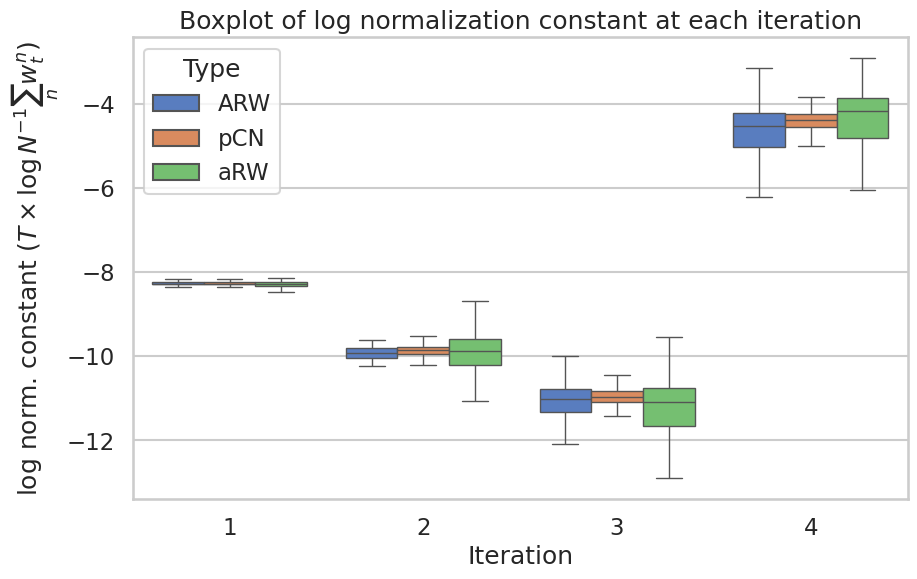

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#construct all dfs

my_dfs = {proposal: 
              [
                  pd.DataFrame(log_normalization_constants_facteur[proposal][idx], columns=list(range(1, max_temp_idx_per_proposal[proposal]+1))).assign(Type=proposal) 
                  for idx in range(len(idx_proposal[proposal]))]
           for proposal in idx_proposal
         }

#


# Combine the DataFrames
combined_df = pd.concat([pd.concat([df for df in my_dfs[proposal]]) for proposal in idx_proposal])

# Melt the combined DataFrame to long-form
melted_df = combined_df.melt(id_vars=['Type'], var_name='Variable', value_name='Value')


# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Variable', y='Value', hue='Type', data=melted_df, showfliers=False)

# Add titles and labels
plt.title('Boxplot of log normalization constant at each iteration')
plt.xlabel('Iteration')
plt.ylabel(r'log norm. constant ($T\times \log N^{-1} \sum_n w_t^n$)')

# Show the plot
plt.savefig(DIR+"boxplot.png")

/tmp/ipykernel_584966/3676243617.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_584966/3676243617.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


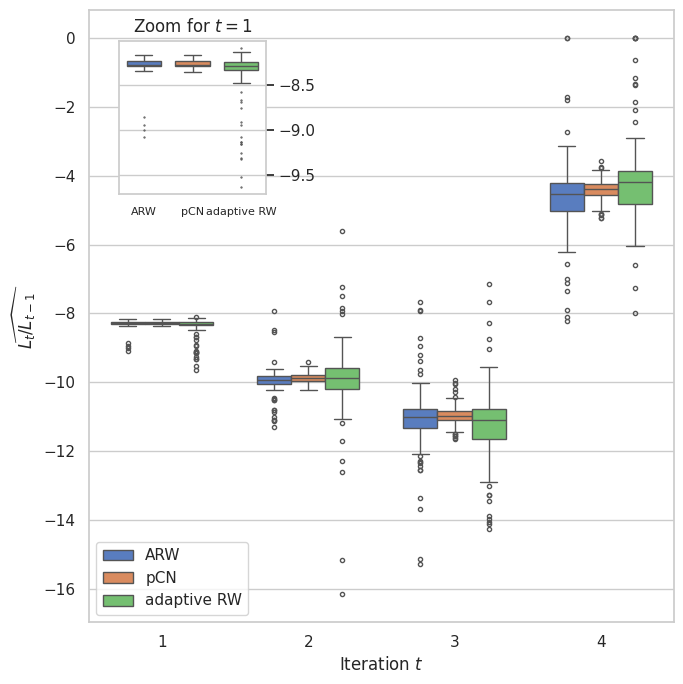

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Set clean style
sns.set(style='whitegrid', palette='muted', font_scale=1.0)

# Prepare data
dfs = []
for proposal in idx_proposal:
    for idx in range(len(idx_proposal[proposal])):
        temp_df = pd.DataFrame(
            log_normalization_constants_facteur[proposal][idx][:, :max_temp_idx_per_proposal[proposal]],
            columns=range(1, max_temp_idx_per_proposal[proposal]+1)
        ).assign(Type=proposal)
        dfs.append(temp_df)

melted_df = pd.concat(dfs).melt(id_vars=['Type'], var_name='Iteration', value_name='Value')

# Create figure
fig, ax = plt.subplots(figsize=(7, 7))

# Main plot
sns.boxplot(
    x='Iteration',
    y='Value',
    hue='Type',
    data=melted_df,
    ax=ax,
    linewidth=1,
    width=0.7,
    fliersize=3
)

# Inset plot with adjusted borderpad
ax_inset = inset_axes(ax, width="25%", height="25%", loc='upper left', borderpad=2.)
sns.boxplot(
    x='Type',
    y='Value',
    data=melted_df[melted_df['Iteration'] == 1],
    ax=ax_inset,
    palette='muted',
    linewidth=1,
    width=0.7,
    fliersize=3*1/5
)

# Move y-axis labels to the right for the inset plot
ax_inset.yaxis.set_ticks_position('right')
ax_inset.yaxis.set_label_position('right')

ax_inset.tick_params(axis='x', labelsize=8)

# Styling
ax.set(xlabel=r'Iteration $t$', ylabel=r'$\widehat{L_t/L_{t-1}}$')
ax_inset.set(title=r'Zoom for $t=1$', xlabel='', ylabel='')

# Clean legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)

plt.tight_layout()
plt.savefig(DIR + "log_normalisation.pdf", dpi=300, bbox_inches='tight')
plt.show()
